# Linear regression models to study MBD4 repair enzyme mechanism

In [1]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error
from itertools import combinations
import logomaker
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import Lasso, LassoCV
from statsmodels.stats.multitest import multipletests
import os

In [2]:
# load data:
df = pd.read_csv('data/MBD4_binding_NNNTNNN_processed_normalized.csv')
df

,Flanks,ln_FI_normalized
0,AAATAAA,5.295544
1,AAATAAC,5.247268
2,AAATAAG,5.301766
3,AAATAAT,5.262567
4,AAATACA,5.653878
...,...,...
4091,TTTTTGT,5.846680
4092,TTTTTTA,4.990610
4093,TTTTTTC,5.099209
4094,TTTTTTG,5.169654


# Simpler linear regression - additivity

In [3]:
# one hot encoding:
context_columns = ['pos_' + str(i) for i in (-3,-2,-1,0,1,2,3)]
df[context_columns] = df['Flanks'].apply(lambda x: pd.Series(list(x)))
df

,Flanks,ln_FI_normalized,pos_-3,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3
0,AAATAAA,5.295544,A,A,A,T,A,A,A
1,AAATAAC,5.247268,A,A,A,T,A,A,C
2,AAATAAG,5.301766,A,A,A,T,A,A,G
3,AAATAAT,5.262567,A,A,A,T,A,A,T
4,AAATACA,5.653878,A,A,A,T,A,C,A
...,...,...,...,...,...,...,...,...,...
4091,TTTTTGT,5.846680,T,T,T,T,T,G,T
4092,TTTTTTA,4.990610,T,T,T,T,T,T,A
4093,TTTTTTC,5.099209,T,T,T,T,T,T,C
4094,TTTTTTG,5.169654,T,T,T,T,T,T,G


In [4]:
# Define nucleotides
bases = ['A', 'C', 'G', 'T']
base_to_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
# Make sure ACGT indexing
base_to_index

{'A': 0, 'C': 1, 'G': 2, 'T': 3}

In [5]:
# One hot encoding flanks:
def one_hot_encode_flanks(row):
    positions = [row['pos_-3'],row['pos_-2'], row['pos_-1'], row['pos_1'], row['pos_2'], row['pos_3']]
    encoding = np.zeros((6, 4))  # 6 positions x 4 bases
    for i, base in enumerate(positions):
        if base in base_to_index:  # skip lesion in pos 0
            encoding[i, base_to_index[base]] = 1
    return encoding.flatten()

In [6]:
df['one_hot'] = df.apply(one_hot_encode_flanks, axis=1)
df

,Flanks,ln_FI_normalized,pos_-3,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3,one_hot
0,AAATAAA,5.295544,A,A,A,T,A,A,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
1,AAATAAC,5.247268,A,A,A,T,A,A,C,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
2,AAATAAG,5.301766,A,A,A,T,A,A,G,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
3,AAATAAT,5.262567,A,A,A,T,A,A,T,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
4,AAATACA,5.653878,A,A,A,T,A,C,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
...,...,...,...,...,...,...,...,...,...,...
4091,TTTTTGT,5.846680,T,T,T,T,T,G,T,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4092,TTTTTTA,4.990610,T,T,T,T,T,T,A,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4093,TTTTTTC,5.099209,T,T,T,T,T,T,C,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4094,TTTTTTG,5.169654,T,T,T,T,T,T,G,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


### train-test split

In [7]:
X = np.vstack(df['one_hot'].values)   #24 features
y = df['ln_FI_normalized'].values    

# define x, y train and test:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape, X_test.shape

((3276, 24), (820, 24))

In [9]:
reg = LinearRegression().fit(X_train, y_train)

# Predictions on test set
y_pred = reg.predict(X_test)

# Metrics
r2_train = reg.score(X_train, y_train)           # R^2 on train
r2_test  = reg.score(X_test, y_test)             # R^2 on test
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)

print(f"R^2 (train): {r2_train:.3f}")
print(f"R^2 (test):  {r2_test:.3f}")
print(f"RMSE (test): {rmse_test:.4f}")
print("Coefficients shape:", reg.coef_.shape)

R^2 (train): 0.785
R^2 (test):  0.789
RMSE (test): 0.6920
Coefficients shape: (24,)


In [10]:
reg.coef_, reg.intercept_

(array([ 0.08270158, -0.24017317,  0.04736746,  0.11010413,  0.52675975,
         0.16303493, -0.25792978, -0.4318649 , -0.20517307, -0.38875433,
        -0.55017602,  1.14410342, -0.15601704, -0.87654762,  1.74595696,
        -0.71339229, -0.25748613, -0.11562334,  0.17756474,  0.19554472,
         0.11718815, -0.15858977, -0.06366146,  0.10506308]),
 np.float64(5.74785279215148))

In [11]:
# Predictions on test data
y_pred = reg.predict(X_test)

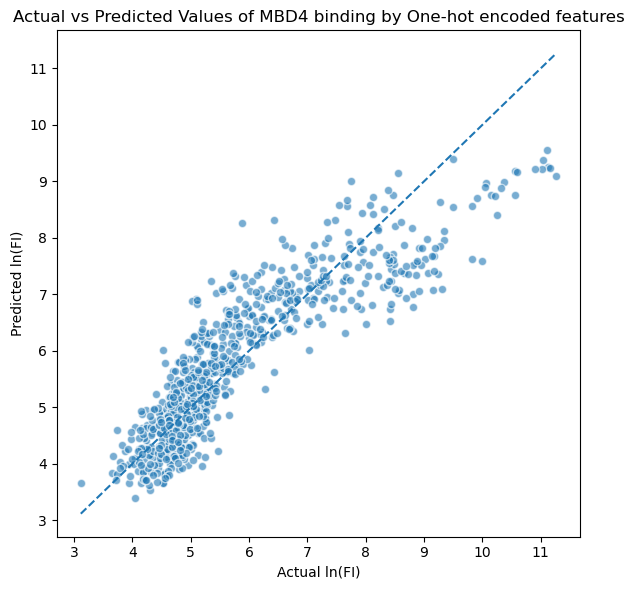

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='w')
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle='--')
plt.xlabel("Actual ln(FI)")
plt.ylabel("Predicted ln(FI)")
plt.title("Actual vs Predicted Values of MBD4 binding by One-hot encoded features")
plt.tight_layout()
plt.show()

### Create PWM logo

In [13]:
# reshape mono coefficients: 24 -> (6 positions, 4 bases)
coef_matrix = reg.coef_.reshape(6, 4)   # one-hot flattened as [A,C,G,T] per position

# integer positions for the x-axis
pos_int   = [-3, -2, -1, 1, 2, 3]
bases     = ['A','C','G','T']

df_logo = pd.DataFrame(coef_matrix, columns=bases, index=pos_int)
df_logo # these are the model's coeffs

,A,C,G,T
-3,0.082702,-0.240173,0.047367,0.110104
-2,0.526760,0.163035,-0.257930,-0.431865
-1,-0.205173,-0.388754,-0.550176,1.144103
1,-0.156017,-0.876548,1.745957,-0.713392
2,-0.257486,-0.115623,0.177565,0.195545
3,0.117188,-0.158590,-0.063661,0.105063


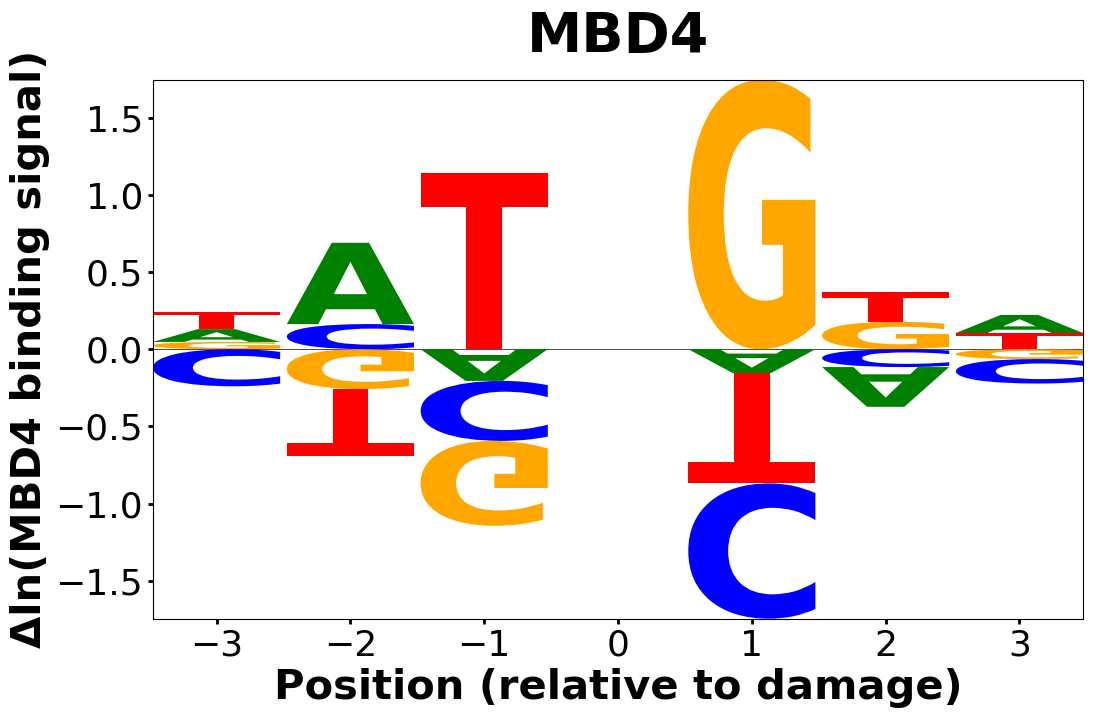

In [15]:
# Make PWM figure
fig, ax = plt.subplots(figsize=(12, 7))

logomaker.Logo(df_logo,ax=ax,shade_below=0.0,  fade_below=0.0)  

# Customize labels, ticks, title
ax.set_ylabel('Δln(MBD4 binding signal)', fontsize=30, fontweight='bold')
ax.set_xlabel('Position (relative to damage)', fontsize=30, fontweight='bold')
ax.set_title('MBD4', fontsize=40, fontweight='bold', pad=20)

# Tick sizes
ax.tick_params(axis='x', labelsize=26, width=2)
ax.tick_params(axis='y', labelsize=26, width=2)

# linear regression with dependencies between adjacent positions

In [16]:
df

,Flanks,ln_FI_normalized,pos_-3,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3,one_hot
0,AAATAAA,5.295544,A,A,A,T,A,A,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
1,AAATAAC,5.247268,A,A,A,T,A,A,C,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
2,AAATAAG,5.301766,A,A,A,T,A,A,G,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
3,AAATAAT,5.262567,A,A,A,T,A,A,T,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
4,AAATACA,5.653878,A,A,A,T,A,C,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
...,...,...,...,...,...,...,...,...,...,...
4091,TTTTTGT,5.846680,T,T,T,T,T,G,T,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4092,TTTTTTA,4.990610,T,T,T,T,T,T,A,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4093,TTTTTTC,5.099209,T,T,T,T,T,T,C,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4094,TTTTTTG,5.169654,T,T,T,T,T,T,G,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


In [17]:
# Define columns and create dinucleotide features 
mono_cols = ['pos_-3','pos_-2','pos_-1','pos_1','pos_2','pos_3']

# Adjacent pairs:
df = df.copy()
df['di_-3_-2'] = df['pos_-3'] + df['pos_-2']
df['di_-2_-1'] = df['pos_-2'] + df['pos_-1']
df['di_1_2']   = df['pos_1']  + df['pos_2']
df['di_2_3']   = df['pos_2']  + df['pos_3']

# include cross-lesion interaction (-1, +1) 
df['di_-1_1'] = df['pos_-1'] + df['pos_1']

di_cols = ['di_-3_-2','di_-2_-1','di_1_2','di_2_3', 'di_-1_1']
df

,Flanks,ln_FI_normalized,pos_-3,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3,one_hot,di_-3_-2,di_-2_-1,di_1_2,di_2_3,di_-1_1
0,AAATAAA,5.295544,A,A,A,T,A,A,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AA,AA,AA
1,AAATAAC,5.247268,A,A,A,T,A,A,C,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AA,AC,AA
2,AAATAAG,5.301766,A,A,A,T,A,A,G,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AA,AG,AA
3,AAATAAT,5.262567,A,A,A,T,A,A,T,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AA,AT,AA
4,AAATACA,5.653878,A,A,A,T,A,C,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AC,CA,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,TTTTTGT,5.846680,T,T,T,T,T,G,T,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TT,TG,GT,TT
4092,TTTTTTA,4.990610,T,T,T,T,T,T,A,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TT,TT,TA,TT
4093,TTTTTTC,5.099209,T,T,T,T,T,T,C,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TT,TT,TC,TT
4094,TTTTTTG,5.169654,T,T,T,T,T,T,G,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TT,TT,TG,TT


In [18]:
#  One-hot encoders for mono and di features 
bases = ['A','C','G','T']
dinucs = [a+b for a in bases for b in bases]  # 16 ordered combos: AA, AC, ..., TT

mono_encoder = OneHotEncoder(categories=[bases]*len(mono_cols),
                             handle_unknown='ignore', sparse_output=False)
di_encoder   = OneHotEncoder(categories=[dinucs]*len(di_cols),
                             handle_unknown='ignore', sparse_output=False)

# ColumnTransformer to combine both sets 
ct = ColumnTransformer(
    transformers=[
        ('mono', mono_encoder, mono_cols),
        ('di',   di_encoder,   di_cols),
    ],
    remainder='drop'
)

### CV for a hint on alpha's range + inspect closely to pick the best tradeoff between # of features and R squared

In [19]:
X = df[mono_cols + di_cols]
y = df['ln_FI_normalized'].values

# 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [20]:
X_train.shape, X_val.shape, y_test.shape

((2457, 11), (819, 11), (820,))

In [21]:
alpha_grid = np.logspace(-4, -1, 30)  
lasso_cv_model = make_pipeline(
    ct,
    LassoCV(alphas=alpha_grid, cv=5, max_iter=100000, random_state=42)
)
lasso_cv_model.fit(X_train, y_train)

# Extract best alpha
lasso_cv = lasso_cv_model.named_steps['lassocv']
best_alpha = lasso_cv.alpha_

print(f"Best alpha from CV: {best_alpha:.5g}")
print(f"R² (Train): {lasso_cv_model.score(X_train, y_train):.4f}")
print(f"# non-zero features: {np.sum(lasso_cv.coef_ != 0)}")

Best alpha from CV: 0.00016103
R² (Train): 0.9015
# non-zero features: 72


In [22]:
manual_alphas = sorted(set([
    best_alpha * f for f in [1, 1.5, 2, 5, 10,20,30,50]
]))

manual_results = []
for alpha in manual_alphas:
    model = make_pipeline(ct, Lasso(alpha=alpha, max_iter=100000))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    manual_results.append({
        'alpha': alpha,
        'train_R2': model.score(X_train, y_train),
        'val_R2': r2_score(y_val, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_pred)),
        #mse_test = mean_squared_error(y_test, y_pred)
        #rmse_test = np.sqrt(mse_test)
        'n_features': np.sum(model.named_steps['lasso'].coef_ != 0)
    })

manual_df = pd.DataFrame(manual_results)
manual_df

,alpha,train_R2,val_R2,RMSE,n_features
0,0.000161,0.901517,0.882227,0.480019,72
1,0.000242,0.901505,0.882200,0.480073,72
2,0.000322,0.901487,0.882168,0.480138,70
3,0.000805,0.901283,0.881844,0.480798,66
4,0.001610,0.900622,0.880911,0.482692,62
5,0.003221,0.898253,0.877681,0.489194,54
6,0.004831,0.894828,0.873336,0.497808,49
7,0.008051,0.886190,0.862635,0.518408,41


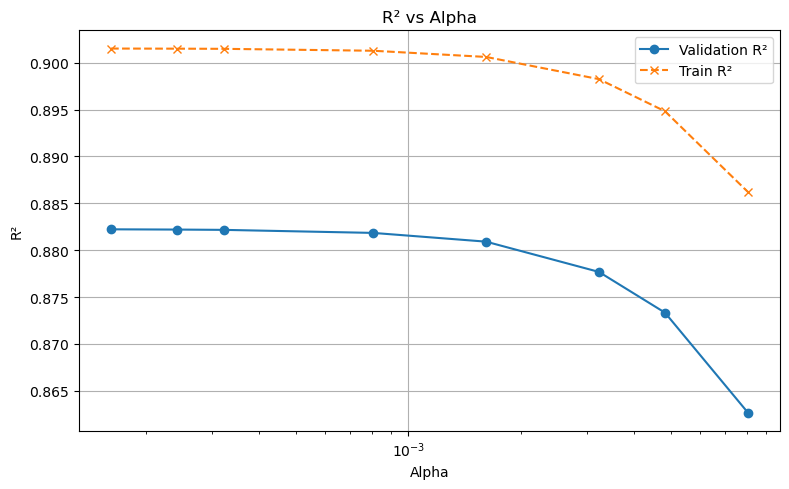

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(manual_df['alpha'], manual_df['val_R2'], 'o-', label='Validation R²')
plt.plot(manual_df['alpha'], manual_df['train_R2'], 'x--', label='Train R²')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("R² vs Alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

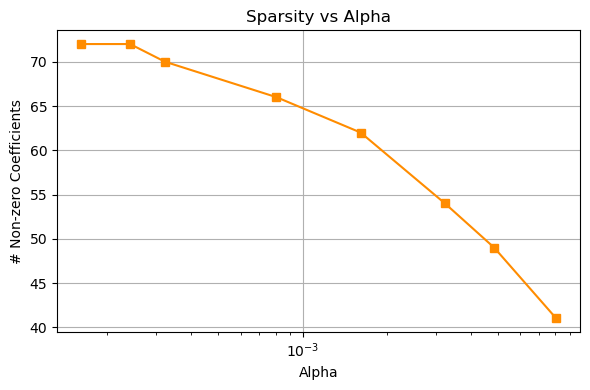

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(manual_df['alpha'], manual_df['n_features'], 's-', color='darkorange')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("# Non-zero Coefficients")
plt.title("Sparsity vs Alpha")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
tolerance = 0.005
max_val_r2 = manual_df['val_R2'].max()
within_tolerance = manual_df[manual_df['val_R2'] >= (max_val_r2 - tolerance)]
sweet_spot = within_tolerance.sort_values(by='n_features').iloc[0]

print(f" Sweet spot alpha: {sweet_spot['alpha']:.5g}")
print(f"    → Val R²: {sweet_spot['val_R2']:.4f}")
print(f"    → Non-zero features: {int(sweet_spot['n_features'])}")

best_alpha = sweet_spot['alpha']

 Sweet spot alpha: 0.0032205
    → Val R²: 0.8777
    → Non-zero features: 54


In [26]:
final_model = make_pipeline(ct, Lasso(alpha=best_alpha, max_iter=100000))
final_model.fit(X_train, y_train)
y_pred_test = final_model.predict(X_test)

print(f" Test R²: {r2_score(y_test, y_pred_test):.4f}")
print(f" Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

 Test R²: 0.8897
 Test RMSE: 0.5007


In [27]:
coef_array = final_model.named_steps['lasso'].coef_
feature_names = ct.get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef_array
}).sort_values("Coefficient", ascending=False)

# Report number of coefficients
n_total = len(coef_array)
n_nonzero = np.sum(coef_array != 0)
print(f" Total features: {n_total}")
print(f" Non-zero (selected) features: {n_nonzero}")
print(f" Zeroed-out features: {n_total - n_nonzero}")

 Total features: 104
 Non-zero (selected) features: 54
 Zeroed-out features: 50


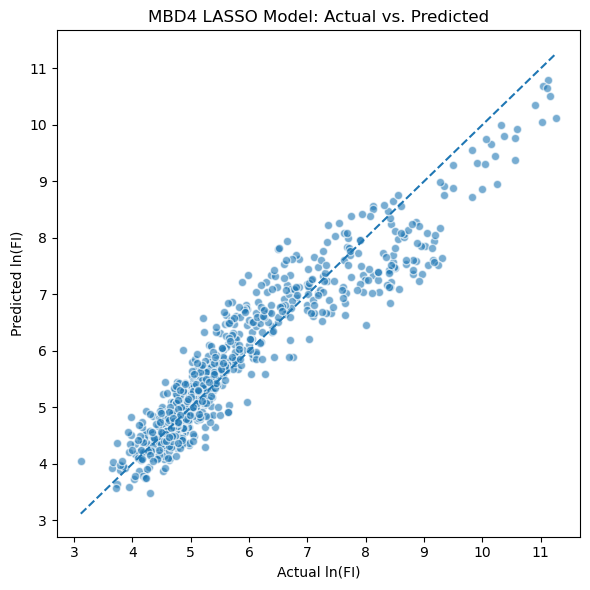

In [28]:
# Plot actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w')
lo, hi = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
plt.plot([lo, hi], [lo, hi], linestyle='--')
plt.xlabel("Actual ln(FI)")
plt.ylabel("Predicted ln(FI)")
plt.title("MBD4 LASSO Model: Actual vs. Predicted")
plt.tight_layout()
plt.show()

In [29]:
# Show top coefficients
feature_names = final_model.named_steps['columntransformer'].get_feature_names_out()
coefs = final_model.named_steps['lasso'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
nz = coef_df[coef_df['coef'] != 0].copy()
nz['abs'] = nz['coef'].abs()
nz = nz.sort_values(by='abs', ascending=False)
print(f"Top features:\n")
display(nz.head(15))

Top features:



,feature,coef,abs
14,mono__pos_1_G,1.861747,1.861747
11,mono__pos_-1_T,1.203903,1.203903
55,di__di_-2_-1_TT,-1.094402,1.094402
102,di__di_-1_1_TG,0.857856,0.857856
66,di__di_1_2_GG,-0.750889,0.750889
100,di__di_-1_1_TA,0.728286,0.728286
43,di__di_-2_-1_AT,0.639795,0.639795
67,di__di_1_2_GT,0.603178,0.603178
50,di__di_-2_-1_GG,-0.432594,0.432594
83,di__di_2_3_GT,0.428103,0.428103
